In [2]:
from utils.constantes import DATA_CLEAN_PATH, PARENT_PATH
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from datetime import datetime


In [2]:
def nombre_aglomerado(codigo):
    """
    Devuelve el nombre del aglomerado a partir de su código.

    Args:
        codigo (str): Código del aglomerado.

    Returns:
        str or None: Nombre del aglomerado o None si no existe.
    """
    dic_aglomerados = {
        '2': 'Gran La Plata',
        '3': 'Bahía Blanca - Cerri',
        '4': 'Gran Rosario',
        '5': 'Gran Santa Fé',
        '6': 'Gran Paraná',
        '7': 'Posadas',
        '8': 'Gran Resistencia',
        '9': 'Comodoro Rivadavia - Rada Tilly',
        '10': 'Gran Mendoza',
        '12': 'Corrientes',
        '13': 'Gran Córdoba',
        '14': 'Concordia',
        '15': 'Formosa',
        '17': 'Neuquén - Plottier',
        '18': 'Santiago del Estero - La Banda',
        '19': 'Jujuy - Palpalá',
        '20': 'Río Gallegos',
        '22': 'Gran Catamarca',
        '23': 'Gran Salta',
        '25': 'La Rioja',
        '26': 'Gran San Luis',
        '27': 'Gran San Juan',
        '29': 'Gran Tucumán - Tafí Viejo',
        '30': 'Santa Rosa - Toay',
        '31': 'Ushuaia - Río Grande',
        '32': 'Ciudad Autónoma de Buenos Aires',
        '33': 'Partidos del GBA',
        '34': 'Mar del Plata',
        '36': 'Río Cuarto',
        '38': 'San Nicolás - Villa Constitución',
        '91': 'Rawson - Trelew',
        '93': 'Viedma - Carmen de Patagones'
    }
    return dic_aglomerados.get(codigo)

In [3]:
archivo_clean_path = DATA_CLEAN_PATH / "usu_clean_individual.csv"
df = pd.read_csv(archivo_clean_path, delimiter=",",low_memory=False)

df

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PONDIH,CH04_str,NIVEL_ED_str,CONDICION_LABORAL,UNIVERSITARIO
0,TQRMNOPUTHLMKQCDEGGFB00852588,2024,1,1,3,1,42,S,10,439,...,12.0,12,12.0,NaN,12,0,femenino,secundario incompleto,ocupado dependiente,0
1,TQRMNOPUTHLMKQCDEGGFB00852588,2024,1,1,4,1,42,S,10,439,...,12.0,12,12.0,NaN,12,0,femenino,superior o universitario,inactivo,1
2,TQRMNOPUTHLMKQCDEGGFB00852588,2024,1,1,5,0,42,S,10,439,...,12.0,12,12.0,NaN,12,0,femenino,sin informacion,fuera de categoria,0
3,TQRMNOPPWHLLKRCDEGGFB00852574,2024,1,1,1,1,42,S,10,675,...,6.0,6,6.0,NaN,6,1610,masculino,secundario completo,ocupado dependiente,0
4,TQRMNOPPWHLLKRCDEGGFB00852574,2024,1,1,2,1,42,S,10,675,...,6.0,6,6.0,NaN,6,1610,femenino,secundario completo,ocupado dependiente,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141531,TQRMNOTTSHLNKNCDEHMHF00806207,2023,3,1,2,1,42,N,26,213,...,8.0,9,NaN,8.0,9,218,masculino,primario incompleto,inactivo,2
141532,TQRMNOUTXHJOKOCDEHMHF00784706,2023,3,1,1,1,42,N,26,164,...,2.0,2,NaN,2.0,2,176,masculino,primario incompleto,inactivo,0
141533,TQRMNOUTXHJOKOCDEHMHF00784706,2023,3,1,2,1,42,N,26,164,...,2.0,2,NaN,2.0,2,176,femenino,primario incompleto,inactivo,0
141534,TQRMNOUTXHJOKOCDEHMHF00784706,2023,3,1,3,1,42,N,26,164,...,2.0,2,NaN,2.0,2,176,masculino,primario incompleto,inactivo,0


In [4]:
df['PP09A_ESP'] = df['PP09A_ESP'].fillna(0)
df['PP09A_ESP']

0         0
1         0
2         0
3         0
4         0
         ..
141531    0
141532    0
141533    0
141534    0
141535    0
Name: PP09A_ESP, Length: 141536, dtype: object

In [5]:
df_anios =  sorted(df["ANO4"].astype(str).unique())
df_trimestres = sorted(df['TRIMESTRE'].astype(str).unique())
# anio_seleccionado = todos 


In [6]:
# df con columnas de edad y sexo 
df_filtrado = df[["PONDERA","CH04", "CH06"]].copy()


rango_anios = range(0,101,10)
etiquetas =  [f"{i}-{i+9}" for i in rango_anios[:-1]] 

df_filtrado["CH06"] = pd.to_numeric(df_filtrado["CH06"], errors="coerce")
df_filtrado["grupos_edad"] = pd.cut(df_filtrado["CH06"],bins=rango_anios , labels=etiquetas)

df_filtrado["CH04"] = df_filtrado["CH04"].apply(lambda x: "M" if x == 1 else "F")
df_filtrado = df_filtrado.groupby(["CH04","grupos_edad"])["PONDERA"].sum().reset_index()

df_filtrado


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3108\1876331794.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado = df_filtrado.groupby(["CH04","grupos_edad"])["PONDERA"].sum().reset_index()


,CH04,grupos_edad,PONDERA
0,F,0-9,6344011
1,F,10-19,7074084
2,F,20-29,6513498
3,F,30-39,6342964
4,F,40-49,6268662
5,F,50-59,4511986
6,F,60-69,3946047
7,F,70-79,2835265
8,F,80-89,1137365
9,F,90-99,194473


In [7]:
df_hombres = df_filtrado[df_filtrado["CH04"] == 'M'].copy()
df_mujeres = df_filtrado[df_filtrado["CH04"] == 'F'].copy()
df_pivot = df_filtrado.pivot(index="grupos_edad",columns="CH04",values="PONDERA")
df_pivot

CH04,F,M
grupos_edad,,
0-9,6344011,6675557
10-19,7074084,7605320
20-29,6513498,6418416
30-39,6342964,5997451
40-49,6268662,5966694
50-59,4511986,4334821
60-69,3946047,3204617
70-79,2835265,1983256
80-89,1137365,607118


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3108\2999010365.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_hombres["grupos_edad"])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3108\2999010365.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


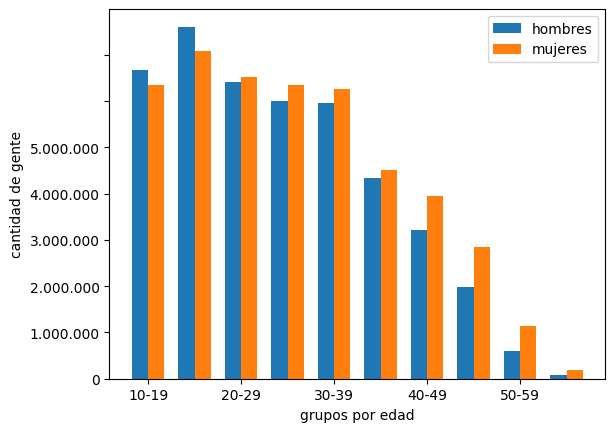

In [8]:
x = np.arange(len(df_hombres.index))
ancho = 0.35 
valores_y = [0,1000000,2000000,3000000,4000000,5000000]
labels_y = ["0","1.000.000","2.000.000","3.000.000","4.000.000","5.000.000"]

fig, ax = plt.subplots()

ax.bar(x - ancho / 2 , df_hombres["PONDERA"], width=ancho , label="hombres")
ax.bar(x + ancho / 2 , df_mujeres["PONDERA"], width=ancho , label="mujeres")

ax.set_xlabel("grupos por edad") 
ax.set_ylabel("cantidad de gente") 


ax.set_xticklabels(df_hombres["grupos_edad"])
ax.set_yticklabels(labels_y)
ax.legend()


In [9]:
ultimo_anio = int(df["ANO4"].unique().max())
df_ult_anio = df[df["ANO4"] == ultimo_anio]
ultimo_trim = int(df_ult_anio["TRIMESTRE"].unique().max())
df_reciente = df_ult_anio[df_ult_anio["TRIMESTRE"] == ultimo_trim]



In [10]:
df_aglomerado = df[["AGLOMERADO","PONDERA","CH06"]].copy()

df_aglomerado['nombre_aglomerado'] = df_aglomerado['AGLOMERADO'].astype(str).apply(nombre_aglomerado)
df_aglomerado = df_aglomerado.groupby(["AGLOMERADO","nombre_aglomerado",]).mean("CH06")
df_aglomerado['CH06'] = df_aglomerado['CH06'].round(2)
df_aglomerado



,,PONDERA,CH06
AGLOMERADO,nombre_aglomerado,,
2,Gran La Plata,801.439655,35.82
3,Bahía Blanca - Cerri,311.273875,37.42
4,Gran Rosario,784.858915,36.74
5,Gran Santa Fé,396.312395,36.50
6,Gran Paraná,201.891243,37.78
7,Posadas,317.099564,35.27
8,Gran Resistencia,325.913055,34.62
9,Comodoro Rivadavia - Rada Tilly,269.621574,34.60
10,Gran Mendoza,562.231317,36.92


Dependencia demográfica = ((Población de 0 a 14 años + Población de 65 años o más) / Población de 15 a 64 años ) * 100



In [11]:
aglo_seleccionado = 32

In [12]:
df_activos = df[(df["AGLOMERADO"] == aglo_seleccionado) & (df["CH06"].between(15,64,inclusive="both")) ][["ANO4","TRIMESTRE","PONDERA"]].copy()
df_inactivos = df[(df["AGLOMERADO"] == aglo_seleccionado) & ( ~df["CH06"].between(15,64,inclusive="both")) ][["ANO4","TRIMESTRE","PONDERA"]].copy()

df_activos = df_activos.groupby(["ANO4","TRIMESTRE"]).sum("PONDERA").reset_index()
df_inactivos = df_inactivos.groupby(["ANO4","TRIMESTRE"]).sum("PONDERA").reset_index()

df_activos["grupo"] = "activos"
df_inactivos["grupo"] = "inactivos"

df_union = pd.concat([df_inactivos, df_activos])

df_union['periodo'] = df_union['ANO4'].astype(str) + 'T' + df_union['TRIMESTRE'].astype(str)
df_union = df_union[["PONDERA","grupo","periodo"]]

df_union = df_union.pivot(index="grupo",columns="periodo",values="PONDERA")

df_union["cociente"] = (df_union["inactivos"] / df_union["activos"] * 100).round(2)
df_union



KeyError: 'inactivos'

In [44]:
df_edad = df[["ANO4","PONDERA","TRIMESTRE","CH06"]].copy()

df_edad['periodo'] = df_edad['ANO4'].astype(str) + 'T' + df_edad['TRIMESTRE'].astype(str)

df_edad = df_edad.groupby(["ANO4","CH06","TRIMESTRE","periodo"]).sum("PONDERA")
df_edad= df_edad.reset_index()

df_edad = df_edad.pivot(index="CH06", columns="periodo",values="PONDERA")

df_edad.index.name = 'edad'
df_edad_2 = df_edad
# Calculamos la media ponderada de la edad por periodo
media_edad_ponderada = ((df_edad.mul(df_edad.index, axis=0)).sum() / df_edad.sum() ).round(2)

# Convertimos a DataFrame si lo querés como tal
media_edad_ponderada_df = media_edad_ponderada.to_frame(name='media_edad')
media_edad_ponderada_df 

def promedio (valor_x, valor_y ): 
    return (valor_x + valor_y) / 2 

for columna in df_edad_2.columns: 
    edad_serie = df_edad_2[columna].dropna().copy()
    indices_edad = edad_serie.index
    if len(edad_serie) % 2 != 0: 
        print(indices_edad[len(indices_edad) // 2])
    else: 
        prom = promedio(indices_edad[(len(indices_edad) // 2 ) - 1 ] , indices_edad[len(indices_edad) // 2 ])
        print(prom)
datos = []
for columna in df_edad.columns: 
    serie = df_edad[columna].dropna()
    datos.append({"periodo" : columna , "mediana" : serie.index.to_series().median()})
    
df_nuevo = pd.DataFrame(datos)
df_nuevo = df_nuevo.set_index("periodo")
df_nuevo

51
50.5
51


,mediana
periodo,
2023T3,51.0
2024T1,50.5
2024T2,51.0


In [3]:
archivo = DATA_CLEAN_PATH / "usu_clean_hogar.csv"
df = pd.read_csv(archivo, delimiter=",", low_memory=False)

anios = df["ANO4"].unique()
## anio_selec = st.selectbox("seleccione el año a buscar", options= anios)
anio_selec = 2023 ####
anio_selec_df = df[df["ANO4"] == anio_selec]

trimestres = anio_selec_df["TRIMESTRE"].unique()
## trim_selec = st.selectbox("seleccione el trimestre a buscar", options= trimestres)
trim_selec = 3 #####
selec_df = anio_selec_df[anio_selec_df["TRIMESTRE"] == trim_selec] 
selec_df

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,REALIZADA,REGION,MAS_500,AGLOMERADO,PONDERA,IV1,...,VII1_1,VII1_2,VII2_1,VII2_2,VII2_3,VII2_4,TIPO_HOGAR,MATERIAL_TECHUMBRE,DENSIDAD_HOGAR,CONDICION_DE_HABITABILIDAD
32557,TQRMNOQQWHKNKMCDEHNHB00797108,2023,3,1,1,42,S,27,148,1.0,...,1,0,98,0,0,0,Nuclear,Material durable,Bajo,buena
32558,TQRMNORQTHKMLRCDEHJGH00790174,2023,3,1,1,40,S,23,270,2.0,...,2,0,98,0,0,0,Nuclear,Material durable,Medio,buena
32559,TQRMNOQSVHLOPOCDEIJAH00807842,2023,3,1,1,1,S,33,2035,1.0,...,2,0,98,0,0,0,Nuclear,Material durable,Bajo,buena
32560,TQRMNORPXHJMKTCDEFIAH00781697,2023,3,1,1,43,S,2,776,1.0,...,1,2,98,0,0,0,Nuclear,Material durable,Bajo,buena
32561,TQRMNOSSRHKNRTCDEIJAH00812823,2023,3,1,1,1,S,33,543,1.0,...,1,0,98,0,0,0,Extendido,Material durable,Alto,buena
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49208,TQRMNOQTRHJOKTCDEIHJF00785235,2023,3,1,1,44,N,31,77,1.0,...,1,0,98,0,0,0,Nuclear,Material durable,Bajo,buena
49209,TQRMNOPXQHMOKUCDEIHJF00811785,2023,3,1,1,44,N,31,257,1.0,...,1,0,98,0,0,0,Nuclear,Material durable,Alto,buena
49210,TQRMNOSSUHMOKUCDEIHJF00811786,2023,3,1,1,44,N,31,270,1.0,...,1,0,98,0,0,0,Extendido,Material durable,Alto,buena
49211,TQRMNOPPRHMOMMCDEFKID00808798,2023,3,1,1,43,S,4,744,1.0,...,1,2,1,0,0,0,Nuclear,Material durable,Medio,buena


In [4]:
# Filtrar por hogares de 4 integrantes y descartar valores del itf desconocidos 
hogares_4_df = selec_df[["ANO4","TRIMESTRE","ITF","PONDERA"]][selec_df["IX_TOT"] >= 4].copy()


hogares_4_df

,ANO4,TRIMESTRE,ITF,PONDERA
32561,2023,3,955000,543
32565,2023,3,0,291
32568,2023,3,240000,103
32569,2023,3,750000,591
32573,2023,3,0,1112
...,...,...,...,...
49202,2023,3,130000,3880
49204,2023,3,0,2205
49209,2023,3,0,257
49210,2023,3,350000,270


In [6]:
# cb = canasta basica 
trim_selec = 1
ruta_cb = PARENT_PATH / "valores-canasta-basica-alimentos-canasta-basica-total-mensual-2016.csv"
cb = pd.read_csv(ruta_cb,delimiter=",")

def convertir_en_fecha (anio,trim):
    if trim != 4:
        if trim == 2:  
            fechas_selec = [str(anio) + "-0" + str((trim * 3) - 2) + "-" + "01",str(anio) + "-0" + str(trim * 3 ) + "-" + "30" ]
        else: 
            fechas_selec = [str(anio) + "-0" + str((trim * 3) - 2) + "-" + "01",str(anio) + "-0" + str(trim * 3 ) + "-" + "31" ]
    else: 
        fechas_selec = [str(anio) + "-" + str((trim * 3) - 2) + "-" + "01",str(anio) + "-" + str(trim * 3 ) + "-" + "31" ]
    return fechas_selec

fechas_selec = convertir_en_fecha(anio_selec,trim_selec)

cb["indice_tiempo"] = pd.to_datetime(cb["indice_tiempo"])

for elem in fechas_selec:
    pd.to_datetime(fechas_selec)

cb_selec = cb[cb["indice_tiempo"].between(fechas_selec[0], fechas_selec[1])]
x = { 
    "prom_pobreza" : ((cb_selec["linea_pobreza"].sum()) / 3 ).round(2),
    "prom_indigencia" : ((cb_selec["linea_indigencia"].sum()) / 3).round(2)
}
cb_selec_prom = pd.DataFrame([x])
cb_selec_prom
def comprobar_promedio(valor): 
    if pd.isna(valor) or valor == 0: 
        return "desconocido"
    elif valor <= cb_selec_prom["prom_indigencia"].iloc[0]:
        return "indigencia"
    elif valor <= cb_selec_prom["prom_pobreza"].iloc[0]:
        return "pobreza"
    else: 
        return "no pobre"
    
hogares_4_df["estado"] = hogares_4_df["ITF"].apply(comprobar_promedio)
hogares_final = hogares_4_df[["estado","PONDERA"]].groupby(["estado"]).sum("PONDERA")
hogares_final
anio_selec = 2023 
trim_selec = 3
convertir_en_fecha(anio_selec,trim_selec)

['2023-07-01', '2023-09-31']